In [3]:
! pwd

/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/two-way


### Netlist Sheaf

In [2]:
import numpy as np
import pysheaf as ps
import scipy
import scipy.linalg
import matplotlib.pyplot as plt
import math

class NetlistSheaf(ps.Sheaf):
    def __init__(self, parts, nets, **kwargs):
        '''
Construct a netlist sheaf using a dictionary of `parts` and `nets`.  
Additional optional arguments accepted as `**kwargs`, so that these can be used as parameters as the sheaf is being built.  

> [!CAUTION]
> This function uses `eval()` to unpack and build Python expressions from strings.  You have been warned; sanitize your input!

Each part is named, and has fields:
* `data_dimension`, 
* `bounds` (optional), 
* `ports`.

The `ports` field is a dictionary naming each port, and associating a string that defines a function for the corresponding restriction map.  

Example:
```
{ "AND2" : { "data_dimension" : 2,
	     "bounds" : "[(0,1)]*2",
	     "ports" : { "IN1" : "lambda x: x[0]",
		       "IN2" : "lambda x: x[1]",
		       "OUT" : "lambda x: x[0]*x[1]" }},
...}
```

Each net is named, and has fields:
* `data_dimension`,
* `bounds` (optional),
* `value` (optional; NB: parsed with `eval()`),
* `optimize` (optional; anything not integer `0` is `True`; default = `True`),
* `constraint` (optional; 'equality' -> `pysheaf.CellConstraintType.EQUALITY`, 'inequality' -> `pysheaf.CellConstraintType.INEQUALITY`, anything else is `pysheaf.CellConstraintType.NONE`)
* `connections`.
Subsequently, `connections` is a list of dictionaries, each one has a `part` and `port` field, which index into the `parts` dictionary above.

```
Example
{
    "A": {
	"data_dimension" : 1,
	"bounds" : "[(0,1)]",
	"connections" : [
	       { "part" : "AND2",
		 "port" : "IN1"}
	   ]
    },
...}
```

> [!TIP]
> The default behavior is that all parts are optimization cells, and that no nets are optimization cells.
        '''
        
        ps.Sheaf.__init__(self)

        self.mNumpyNormType=2

        # First, build the parts (lower level of poset)
        for k,v in parts.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])
                
            self.AddCell(k,
                         ps.Cell('part',
                                 dataDimension = ddim))
                
            self.GetCell(k).SetDataAssignment(ps.Assignment('part',np.zeros((ddim,))))
            self.GetCell(k).mOptimizationCell = True

        # Next, build the nets (upper level of poset)
        for k,v in nets.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])

            self.AddCell(k,
                         ps.Cell('net',
                                 dataDimension = ddim))
            
            try:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',eval(v['value'])))
            except KeyError:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',np.zeros((ddim,))))

            try:
                self.GetCell(k).mOptimizationCell = (v['optimize']!=0)
            except KeyError:
                pass

            try:
                if v['constraint'] == 'inequality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.INEQUALITY
                elif v['constraint'] == 'equality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.EQUALITY
            except KeyError:
                pass

            # Connect each part in this net
            for vp in v['connections']:
                part=vp['part']
                port=vp['port']
                self.AddCoface(part,k,
                               ps.Coface('part','net',
                                         eval(parts[part]['ports'][port])))
        return

In [3]:
import csv
import json
import sys
import numpy as np
import scipy.linalg
import networkx as nx
import pysheaf as ps
import matplotlib.pyplot as plt
sys.path.append('/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/netlist-sheaf/')
import netlist_sheaf
import numpy.random
import numpy.polynomial
from collections import defaultdict

In [4]:
### Example based upon Figure 4 in
# Thorson et al., "Dynamic structural equation models synthesize ecosystem dynamics constrained by ecological mechanisms", DOI: 10.1111/2041-210X.14289
#
# This model uses the netlist sheaf construction.

import csv
import json
import numpy as np
import scipy.linalg
import pysheaf as ps
import matplotlib.pyplot as plt
import netlist_sheaf
from collections import defaultdict

# Names in the Thorson data disagree with their paper
names_dict={
    "wolves" : "wolves",
    "moose" : "moose"
    }

def lag_fcn(npts,ar,x):
    '''Convenience function for building lag matrices'''
    if ar:
        return scipy.linalg.toeplitz(np.concatenate(([0],x[0:ar],np.zeros((npts-ar-1,)))),np.zeros((npts,)))
    else: # Disable autoregression
        return np.eye(npts)

# Load the sheaf structure
parts=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_parts_copy.json'))
parts

{'wolves-block': {'data_dimension': "kwargs['npts']+2",
  'ports': {'in': 'lambda x: x[2:]',
   'crop': "lambda x,ar=kwargs['ar']: x[ar+2:]",
   'out': 'lambda x: x[0]+x[1]*x[2:]',
   'pc': 'lambda x: x[1]',
   'constant': 'lambda x: x[0]'}},
 'moose-block': {'data_dimension': "kwargs['npts']+2",
  'ports': {'in': 'lambda x: x[2:]',
   'crop': "lambda x,ar=kwargs['ar']: x[ar+2:]",
   'out': 'lambda x: x[0]+x[1]*x[2:]',
   'pc': 'lambda x: x[1]',
   'constant': 'lambda x: x[0]'}},
 'moose-lag': {'data_dimension': "kwargs['npts']+kwargs['ar']",
  'ports': {'in': "lambda x,npts=kwargs['npts'],ar=kwargs['ar']: x[ar:]",
   'out': "lambda x,npts=kwargs['npts'],ar=kwargs['ar'],lag_fcn=kwargs['lag_fcn']: np.dot(lag_fcn(npts,ar,x),x[ar:])[ar:]"}},
 'wolves-lag': {'data_dimension': "kwargs['npts']+kwargs['ar']",
  'ports': {'in': "lambda x,npts=kwargs['npts'],ar=kwargs['ar']: x[ar:]",
   'out': "lambda x,npts=kwargs['npts'],ar=kwargs['ar'],lag_fcn=kwargs['lag_fcn']: np.dot(lag_fcn(npts,ar,x),x[a

In [5]:
nets=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_nets_copy.json'))
nets

{'moose': {'data_dimension': "kwargs['npts']",
  'optimize': 1,
  'connections': [{'part': 'wolves-block', 'port': 'in'},
   {'part': 'moose-lag', 'port': 'in'},
   {'part': 'moose-block', 'port': 'out'}]},
 'wolves': {'data_dimension': "kwargs['npts']",
  'optimize': 1,
  'connections': [{'part': 'wolves-block', 'port': 'out'},
   {'part': 'moose-block', 'port': 'in'},
   {'part': 'wolves-lag', 'port': 'in'}]},
 'moose-pc': {'data_dimension': 1,
  'value': '0.6',
  'optimize': 1,
  'constraint': 'equality',
  'connections': [{'part': 'wolves-block', 'port': 'pc'}]},
 'wolves-pc': {'data_dimension': 1,
  'value': '0.6',
  'optimize': 1,
  'constraint': 'equality',
  'connections': [{'part': 'moose-block', 'port': 'pc'}]},
 'moose-lagvar': {'data_dimension': "kwargs['npts']-kwargs['ar']",
  'optimize': 1,
  'connections': [{'part': 'wolves-block', 'port': 'crop'},
   {'part': 'moose-lag', 'port': 'out'}]},
 'wolves-lagvar': {'data_dimension': "kwargs['npts']-kwargs['ar']",
  'optimize':

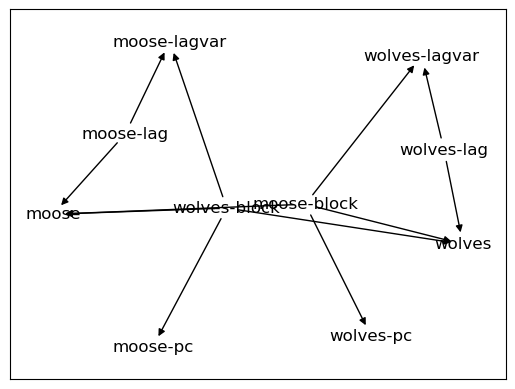

In [6]:

from enum import Enum

class CellConstraintType(Enum):
    EQUALITY = 0
    INEQUALITY = 1

ps.CellConstraintType = CellConstraintType



startyear = 1959
npts = 61
ar = 0
shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)

pos=nx.layout.spring_layout(shf)
nx.draw_networkx_labels(shf,pos)
nx.draw_networkx_edges(shf,pos)
plt.show()

# Load the data; adding in new cells to house the known values
measurements = defaultdict(list)
with open('/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/log_isle_royal_data.csv') as fp:
    reader = csv.DictReader(fp, delimiter = ',')
    idx = 0
    for row in reader:
        for data_name,sheaf_name in names_dict.items():
            if row[data_name] != 'NA':
                year = startyear+idx
                datum = str(year) + "-" + sheaf_name
                value = float(row[data_name])

                measurements[sheaf_name].append((year,value))
                
                shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                shf.AddCoface(sheaf_name,datum,
                              ps.Coface('net','datum', lambda x,idx=idx : x[idx] ))
        
        idx = idx + 1

# Load in DSEM predictions
dsem_values = defaultdict(list)
with open('/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/wolf_moose_dsem.csv') as fp:   
    reader = csv.DictReader(fp, delimiter = ',')
    idx = 0
    for row in reader:
        for data_name,sheaf_name in names_dict.items():
            if row[data_name] != 'NA':
                year = startyear+idx
                datum = str(year) + "-" + sheaf_name
                value = float(row[data_name])

                dsem_values[sheaf_name].append((year,value))        
        idx = idx + 1
    # functions 

===
Consistency radius before optimization: 4.925548505414726
Optimizing...
Consistency radius after optimization: 4.925548443138828
===
Path coefficients:
---
moose-pc : [-2.98665589]
wolves-pc : [-0.29863544]
===
Offsets:
---
wolves-block : 23.33038848671104
moose-block : [ 7.70453975 -0.29749349]
===
Autoregressive cofficients:
---
wolves : []
moose : []

All stalks
---
wolves-block : Star local consistency radius: 3.580606973477463
- -
wolves-block : [23.33038849 -2.98615383  6.7513028   6.72822852  6.729851    6.71795814
  6.76276686  6.68908509  6.6695922   6.69628001  6.76243031  6.77396289
  6.87348118  6.85689718  6.83941978  6.80337357  6.78815856  6.71097258
  6.62153235  6.59351529  6.65689072  6.59529732  6.57552177  6.52117654
  6.67050653  6.89898375  6.75827996  6.75786644  6.7895373   6.82218619
  6.8920098   6.98495917  6.99838286  6.93684842  7.0176843   7.03172843
  7.01347627  6.94734299  6.97084451  6.89009849  6.75454951  6.91812969
  6.75365222  6.71348092  6.84

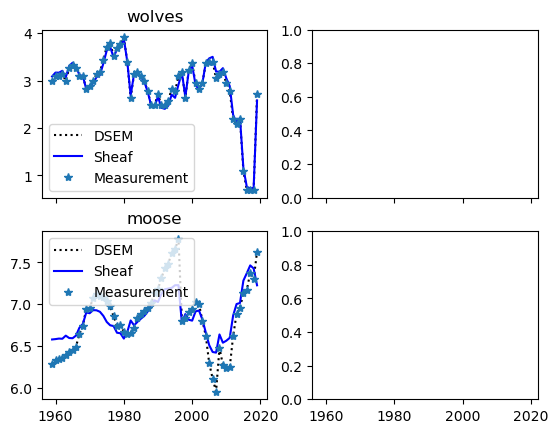

In [10]:
star_consistency = []
total_CR = []

for c in shf.GetCellIndexList():
    shf.MaximallyExtendCell(c)

print('===')
print("Consistency radius before optimization: {}".format(shf.ComputeConsistencyRadius()))

print('Optimizing...')
shf.FuseAssignment()

print("Consistency radius after optimization: {}".format(shf.ComputeConsistencyRadius()))

print('===')
print("Path coefficients:") 
print('---')

for c in shf.GetCellIndexList():
    if "-pc" in c:
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))

print('===')
print("Offsets:")
print('---')

for c in shf.GetCellIndexList():
    if c == 'moose-block':
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue[0:2]))
    elif "-block" in c:
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue[0]))

print('===')
print("Autoregressive cofficients:")
print('---')

for data_name,sheaf_name in names_dict.items():
    try:
        print("{} : {}".format(sheaf_name,shf.GetCell(sheaf_name + "-lag").mDataAssignment.mValue[0:ar]))
    except KeyError:
        pass


print('')
print('==========')
print('All stalks')
print('---')
for c in shf.GetCellIndexList():
    print("{} : Star local consistency radius: {}".format(c,shf.ComputeStarLocalConsistencyRadius(c)))
    print("- -")
    print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))

star_consistency.append(shf.ComputeStarLocalConsistencyRadius(c))
total_CR.append
        
years=[startyear + year for year in range(npts)]

fig = plt.figure()
axes = fig.subplots(2,2, sharex='all')
row = 0
col = 0
for data_name,sheaf_name in names_dict.items():
    axes[row,col].plot([x for x,y in dsem_values[sheaf_name]],[y for x,y in dsem_values[sheaf_name]],'k:',label='DSEM')
    axes[row,col].plot(years,shf.GetCell(sheaf_name).mDataAssignment.mValue,'b',label='Sheaf')
    axes[row,col].plot([x for x,y in measurements[sheaf_name]],[y for x,y in measurements[sheaf_name]],'*',label='Measurement')
    axes[row,col].set_title(sheaf_name)
    axes[row,col].legend()

    row += 1
    if row > 2:
        row = 0
        col += 1

plt.show()

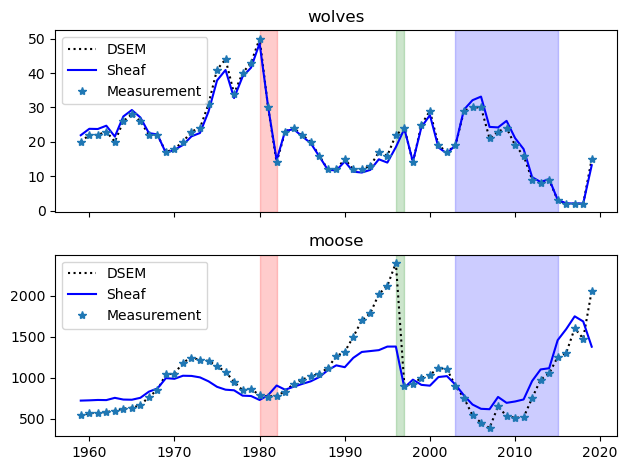

In [35]:
fig = plt.figure()
axes = fig.subplots(2, 1, sharex='all')

for ax, (data_name, sheaf_name) in zip(axes.flat, names_dict.items()):
    ax.plot([x for x,y in dsem_values[sheaf_name]],
            [np.exp(y) for x,y in dsem_values[sheaf_name]],
            'k:', label='DSEM')
    
    ax.plot(years, np.exp(shf.GetCell(sheaf_name).mDataAssignment.mValue), 
            'b', label='Sheaf')
    
    ax.plot([x for x,y in measurements[sheaf_name]],
            [np.exp(y) for x,y in measurements[sheaf_name]],
            '*', label='Measurement')
    
    ax.set_title(sheaf_name)
    ax.legend()

    ax.axvspan(xmin=1980, xmax=1982, color='red', alpha=0.2)
    ax.axvspan(xmin=1996, xmax=1997, color='green', alpha=0.2)
    ax.axvspan(xmin=2003, xmax=2015, color='blue', alpha=0.2)


for ax in axes.flat[len(names_dict):]:
    ax.axis('off')
    
   
plt.tight_layout()
#plt.show()
plt.savefig("Two_way_output.png")